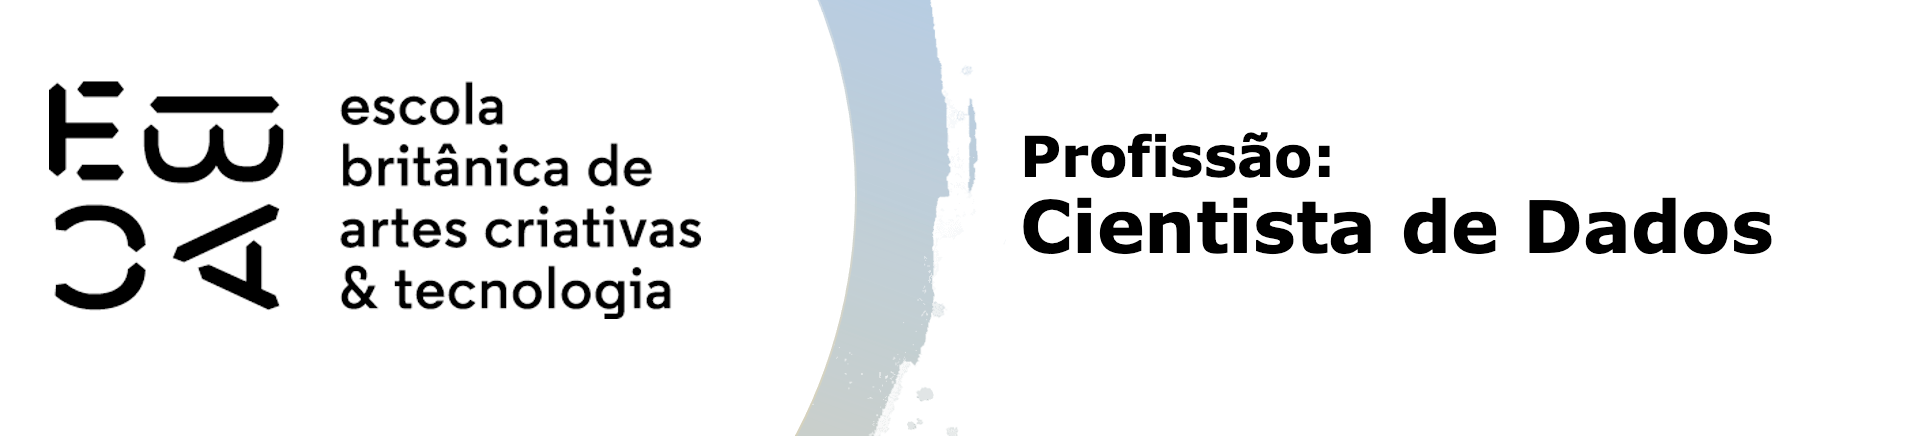

# Tarefa II

Neste projeto, estamos construindo um credit scoring para cartão de crédito, em um desenho amostral com 15 safras, e utilizando 12 meses de performance.

Carregue a base de dados ```credit_scoring.ftr```.

In [1]:
# Importando bibliotecas
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils import resample

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, roc_curve, classification_report

In [2]:
# Importando dados
df = pd.read_feather('./credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


## Amostragem

Separe os três últimos meses como safras de validação *out of time* (oot).

Variáveis:<br>
Considere que a variável ```data_ref``` não é uma variável explicativa, é somente uma variável indicadora da safra, e não deve ser utilizada na modelagem. A variávei ```index``` é um identificador do cliente, e também não deve ser utilizada como covariável (variável explicativa). As restantes podem ser utilizadas para prever a inadimplência, incluindo a renda.


In [3]:
# Criando base de desenvolvimento com dados do ano de 2015 
data = df[df['data_ref'].dt.year == 2015].copy()

# Criando base de validação com dados do ano de 2016
data_unseen = df[df['data_ref'].dt.year == 2016].copy()

print(f'Dimensões da base de desenvolvimento: {data.shape}\nDimensões da base de validação: {data_unseen.shape}')

Dimensões da base de desenvolvimento: (600000, 15)
Dimensões da base de validação: (150000, 15)


In [4]:
# Visualizando quantidade de registros por mês nos dados
data.groupby(by='data_ref', observed=False)['data_ref'].count()

data_ref
2015-01-01    50000
2015-02-01    50000
2015-03-01    50000
2015-04-01    50000
2015-05-01    50000
2015-06-01    50000
2015-07-01    50000
2015-08-01    50000
2015-09-01    50000
2015-10-01    50000
2015-11-01    50000
2015-12-01    50000
Name: data_ref, dtype: int64

In [5]:
# Eliminando colunas que não utilizaremos
data.drop(columns=['data_ref', 'index'], inplace=True)
data_unseen.drop(columns=['data_ref', 'index'], inplace=True)

print(f'Dimensões da base de desenvolvimento: {data.shape}\nDimensões da base de validação: {data_unseen.shape}')

Dimensões da base de desenvolvimento: (600000, 13)
Dimensões da base de validação: (150000, 13)


## Descritiva básica univariada

- Descreva a base quanto ao número de linhas, número de linhas para cada mês em ```data_ref```.
- Faça uma descritiva básica univariada de cada variável. Considere as naturezas diferentes: qualitativas e quantitativas.

In [6]:
# Definindo funções para análise univariada
def classificar_variavel(variavel: pd.Series) -> str:
    '''
    Função para classificar uma variável em 'discreta' ou 'contínua'.

    Parâmetros:
    - variavel: recebe uma Serie do Pandas.

    Retorna:
    - uma string identificando a variável.
    '''
    try:
        num_classes = variavel.nunique()
        dtype = variavel.dtype
        if num_classes >= 6 and dtype in ['int64', 'float64']:
            return 'contínua'
        else:
            return 'discreta'
    except:
        return 'não identificado'

def analise_univariada_quantitativa(variavel: pd.Series) -> None:
    '''
    Função para plotar a análise univariada de uma variável contínua.

    Parâmetros:
    - variavel: recebe o Series do Pandas da variável em questão.
    '''
    tb = pd.DataFrame(variavel.describe().rename({'count': 'contagem', 'mean': 'média', 'std': 'desvio padrão'}))
    display(tb)

    variavel.plot(kind='hist', ylabel='Frequência', title='Histograma de {}'.format(variavel.name.capitalize()))
    plt.show()

def analise_univariada_qualitativa(variavel: pd.Series) -> None:
    '''
    Função para plotar a análise univariada de uma variável discreta.

    Parâmetros:
    - variavel: recebe o Series do Pandas da variável em questão.
    '''
    tb = pd.DataFrame(variavel.value_counts(normalize=True)).rename({'proportion': 'Proporção'}, axis=1)
    display(tb)

    tb.plot(kind='bar', title='Proporção das Classes de {}'.format(variavel.name.capitalize()))
    plt.show()

def analise_univariada(variavel: pd.Series, tipo: str) -> None:
    '''
    Função para conduzir a análise univariada de acordo com o tipo da variável.
    
    Parâmetros:
    - variavel: recebe o Series do Pandas da variável em questão.
    - tipo: recebe o tipo da variável, entre 'discreta' e 'contínua'.

    Retorna:
    - chamado de outra função com base no tipo da variável passado no argumento.
    '''
    if tipo not in ['discreta', 'contínua']:
        return 'Tipo da variável não aceito'
    if tipo == 'discreta':
        return analise_univariada_qualitativa(variavel)
    return analise_univariada_quantitativa(variavel)

In [7]:
# Coletando metadados da base de desenvolvimento
metadata = pd.DataFrame({'dtype': data.dtypes,
                         'num_missings': data.isna().sum(),
                         'num_classes': data.nunique(),
                         'tipo_variavel': [classificar_variavel(data[col]) for col in data],
                         'papel': 'independente'})

# Identificando variável dependente
metadata.loc[metadata.index == 'mau', 'papel'] = 'dependente'

# Visualizando resultado
metadata

,dtype,num_missings,num_classes,tipo_variavel,papel
sexo,object,0,2,discreta,independente
posse_de_veiculo,object,0,2,discreta,independente
posse_de_imovel,object,0,2,discreta,independente
qtd_filhos,int64,0,8,contínua,independente
tipo_renda,object,0,5,discreta,independente
educacao,object,0,5,discreta,independente
estado_civil,object,0,5,discreta,independente
tipo_residencia,object,0,6,discreta,independente
idade,int64,0,47,contínua,independente
tempo_emprego,float64,100875,3004,contínua,independente


,Proporção
sexo,
F,0.673008
M,0.326992


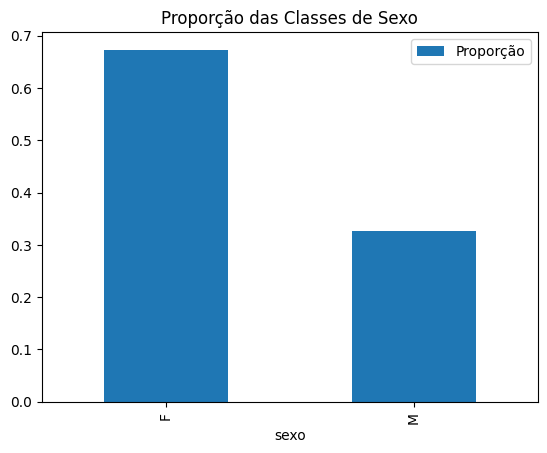

,Proporção
posse_de_veiculo,
N,0.610488
S,0.389512


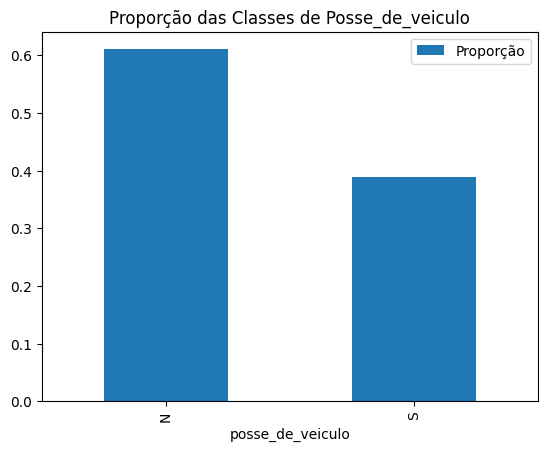

,Proporção
posse_de_imovel,
S,0.671757
N,0.328243


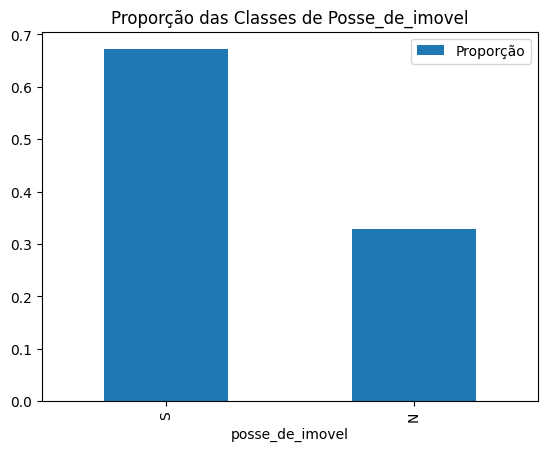

,qtd_filhos
contagem,600000.000000
média,0.433210
desvio padrão,0.739869
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,14.000000


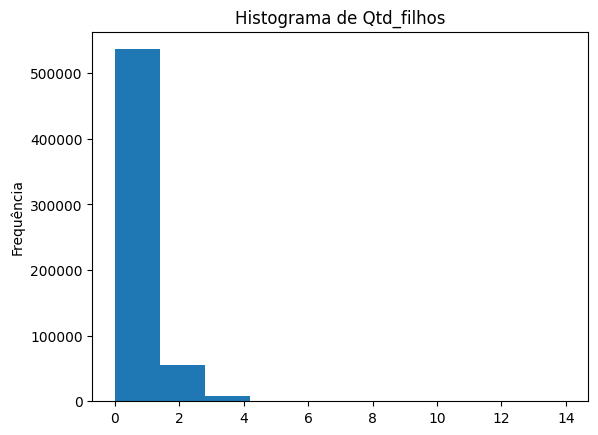

,Proporção
tipo_renda,
Assalariado,0.514100
Empresário,0.230235
Pensionista,0.168545
Servidor público,0.086635
Bolsista,0.000485


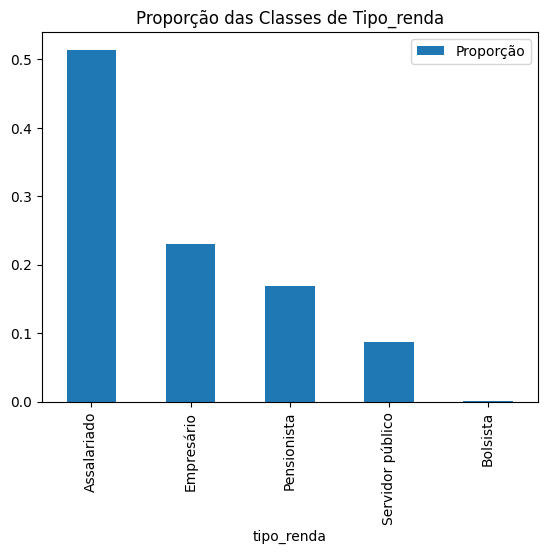

,Proporção
educacao,
Médio,0.675748
Superior completo,0.272400
Superior incompleto,0.039265
Fundamental,0.011502
Pós graduação,0.001085


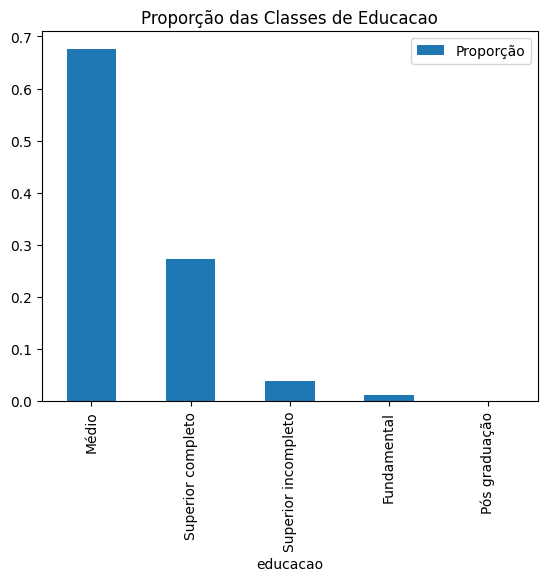

,Proporção
estado_civil,
Casado,0.701915
Solteiro,0.122035
União,0.076847
Separado,0.056980
Viúvo,0.042223


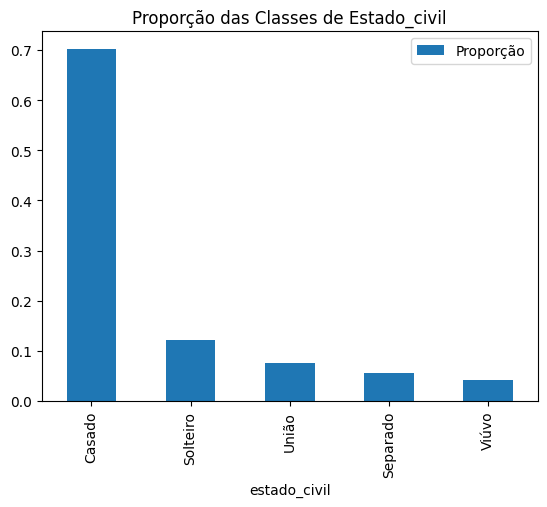

,Proporção
tipo_residencia,
Casa,0.898893
Com os pais,0.044550
Governamental,0.031237
Aluguel,0.013770
Estúdio,0.007160
Comunitário,0.004390


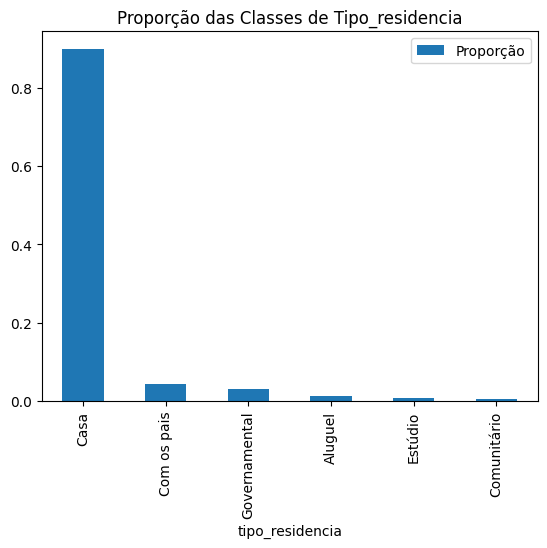

,idade
contagem,600000.000000
média,43.798530
desvio padrão,11.230659
min,22.000000
25%,34.000000
50%,43.000000
75%,53.000000
max,68.000000


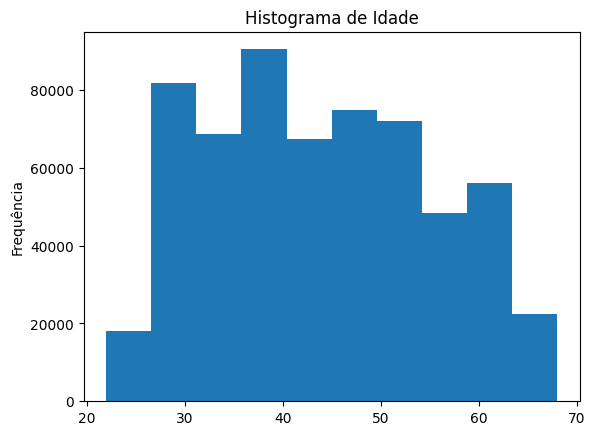

,tempo_emprego
contagem,499125.000000
média,7.747992
desvio padrão,6.688576
min,0.117808
25%,3.049315
50%,6.046575
75%,10.180822
max,42.906849


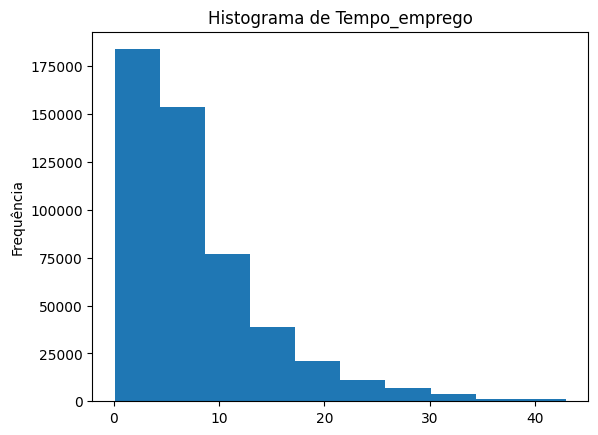

,qt_pessoas_residencia
contagem,600000.000000
média,2.212122
desvio padrão,0.903757
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,15.000000


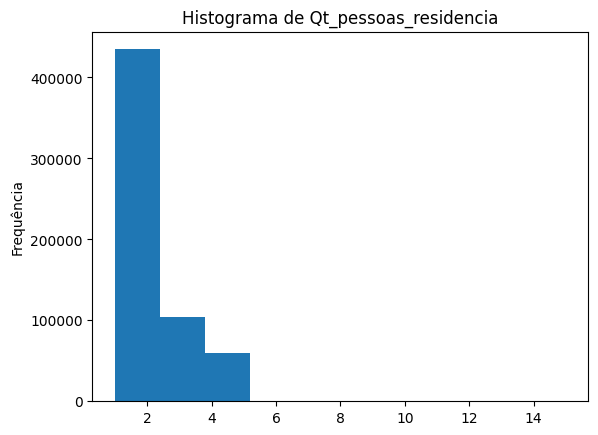

,renda
contagem,6.000000e+05
média,2.722284e+04
desvio padrão,8.737788e+04
min,1.618600e+02
25%,4.670600e+03
50%,9.887580e+03
75%,2.162887e+04
max,4.083986e+06


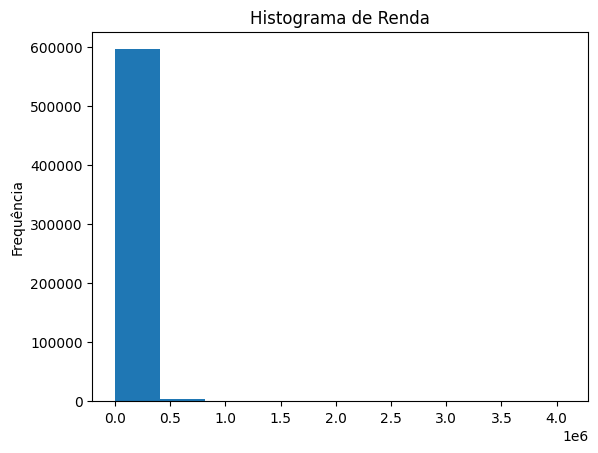

In [8]:
# Conduzindo análise univariada por cada variável na base de desenvolvimento
for col in data:
    if metadata[metadata.index == col]['papel'].iloc[0] != 'independente':
        continue
    else:
        tipo =  metadata[metadata.index == col]['tipo_variavel'].iloc[0]
        analise_univariada(data[col], tipo)

## Descritiva bivariada

Faça uma análise descritiva bivariada de cada variável

In [9]:
# Definindo funções para análise bivariada
def categorizar_variavel(variavel: pd.Series, intervalos: int=10) -> pd.Series:
    '''
    Função para categorizar uma variável contínua.

    Parâmetros:
    - variavel: uma Series do Pandas, sendo essa a variável a ser categorizada.
    - intervalos: um número inteiro que representa o número de intervalos a criar para categorizar a variável.

    Retorna:
    - a Series Pandas da variável categorizada.
    '''
    labels = pd.qcut(variavel, intervalos, duplicates='drop')
    cat_variavel = pd.Series(labels, name=f'cat_{variavel.name}')
    return cat_variavel

def analise_bivariada(variavel: pd.Series, resposta: pd.Series) -> None:
    '''
    Função para conduzir a análise bivariada com base nos cálculos de Weight of Evidence (WOE) e Information Value (IV) das variáveis.

    Parâmetros:
    - variavel: uma Series do Pandas, sendo essa a variável a ser estudada.
    - resposta: uma Series do Pandas, sendo essa a variável resposta binária a ser usada como base.
    '''
    iv, tab = criar_tabela_woe(variavel, resposta)
    
    display(tab)
    print(f'Information Value (IV) da variável {variavel.name}: {iv:.4%}')

    tab['WOE'].drop('All').plot(kind='barh', xlabel='Weight of Evidence', title=f'WOE por Classe da Variável {variavel.name.capitalize()}')
    plt.show()

def criar_tabela_woe(variavel: pd.Series, resposta: pd.Series) -> tuple:
    '''
    Função para construir a tabela cruzada e calcular o Weight of Evidence das classes e Information Value da variável.

    Parâmetros:
    - variavel: uma Series do Pandas, sendo essa a variável a ser estudada.
    - resposta: uma Series do Pandas, sendo essa a variável resposta binária a ser usada como base.

    Retorna:
    - tupla contendo a tabela cruzada e o calculado de information value.
    '''
    # Cria a tabela cruzada
    tab = pd.crosstab(variavel, resposta, margins=True)

    # Calculada as probabilidades do evento e não-evento
    tab['Prop_nao_evento'] = tab[0] / tab[0].sum()
    tab['Prop_evento'] = tab[1] / tab[1].sum()

    # Define um valor para impedir zeros estruturais no cálculo
    epsilon = 1e-10

    # Calcula Weight of Evidence e Information Value parcial das classes
    tab['WOE'] = np.log((tab['Prop_nao_evento'] + epsilon) / (tab['Prop_evento'] + epsilon))
    tab['IV_parcial'] = (tab['Prop_nao_evento'] - tab['Prop_evento']) * tab['WOE']

    # Calcula o Information Value da variável categórica
    iv = tab['IV_parcial'].sum()

    return iv, tab

def classificar_iv(iv: float) -> str:
    '''
    Função para classificar o IV de acordo com a classificação de Naeem Siddiqi.

    Parâmetros:
    - iv: o valor de Information Value da variável.

    Retorna:
    - string com a classificação de IV da variável.
    '''
    if iv < 0.02:
        return 'Inútil'
    elif 0.02 <= iv < 0.1:
        return 'Fraca'
    elif 0.1 <= iv < 0.3:
        return 'Média'
    elif 0.3 <= iv < 0.5:
        return 'Forte'
    return 'Sobreajuste'

Análise Bivariada da Variável Sexo


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
sexo,,,,,,,
F,378318,25487,403805,0.335771,0.347774,-0.035125,0.000422
M,185039,11156,196195,0.164229,0.152226,0.075898,0.000911
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável sexo: 0.1333%


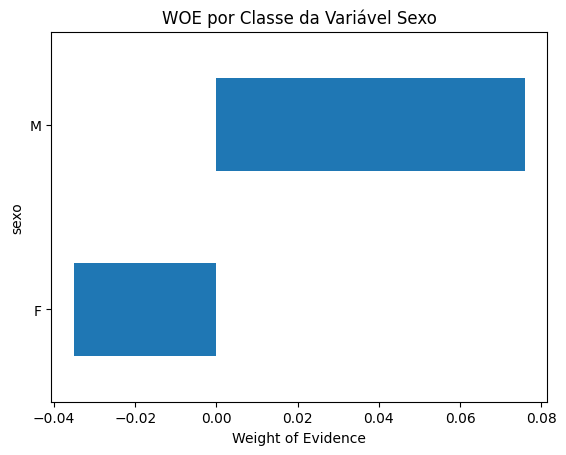

Análise Bivariada da Variável Posse_de_veiculo


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
posse_de_veiculo,,,,,,,
N,343778,22515,366293,0.305116,0.307221,-0.006877,0.000014
S,219579,14128,233707,0.194884,0.192779,0.010862,0.000023
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável posse_de_veiculo: 0.0037%


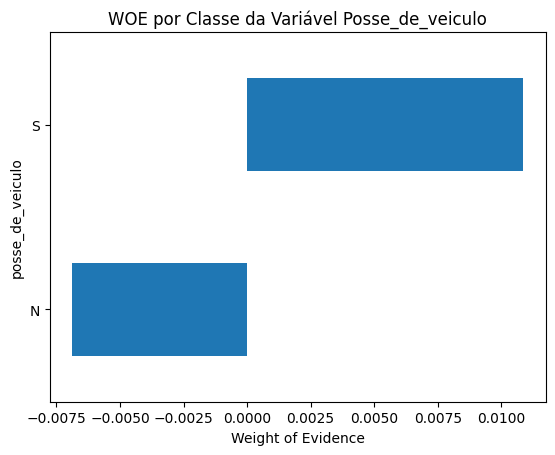

Análise Bivariada da Variável Posse_de_imovel


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
posse_de_imovel,,,,,,,
N,183305,13641,196946,0.16269,0.186134,-0.134620,0.003156
S,380052,23002,403054,0.33731,0.313866,0.072036,0.001689
All,563357,36643,600000,0.50000,0.500000,0.000000,0.000000


Information Value (IV) da variável posse_de_imovel: 0.4845%


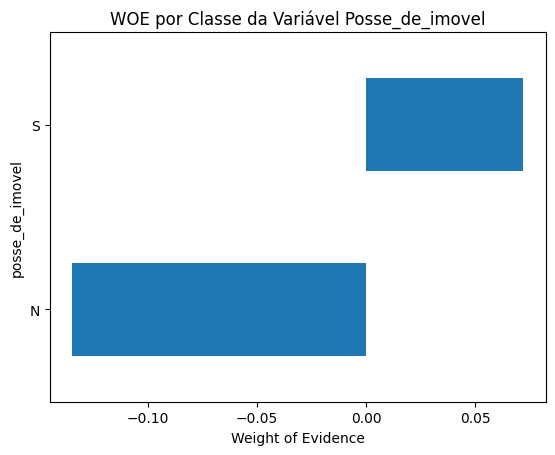

Análise Bivariada da Variável Qtd_filhos


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
cat_qtd_filhos,,,,,,,
"(-0.001, 1.0]",503676,32677,536353,0.447031,0.445883,0.002571,0.000003
"(1.0, 2.0]",52182,3421,55603,0.046313,0.046680,-0.007886,0.000003
"(2.0, 14.0]",7499,545,8044,0.006656,0.007437,-0.110952,0.000087
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável cat_qtd_filhos: 0.0092%


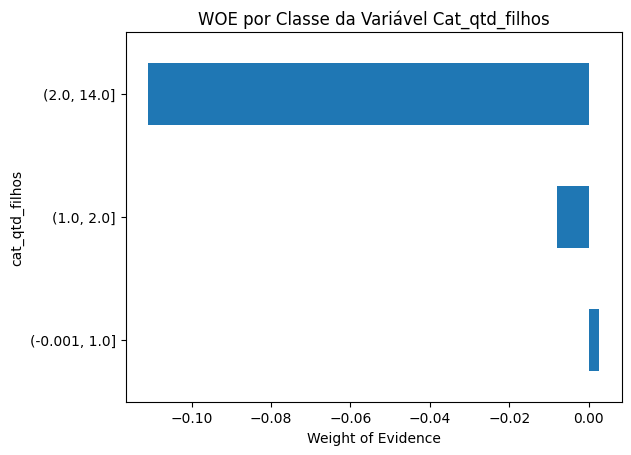

Análise Bivariada da Variável Tipo_renda


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
tipo_renda,,,,,,,
Assalariado,288865,19595,308460,0.256378,0.267377,-0.042006,0.000462
Bolsista,279,12,291,0.000248,0.000164,0.413614,0.000035
Empresário,129935,8206,138141,0.115322,0.111972,0.029478,0.000099
Pensionista,94627,6500,101127,0.083985,0.088694,-0.054550,0.000257
Servidor público,49651,2330,51981,0.044067,0.031793,0.326459,0.004007
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável tipo_renda: 0.4859%


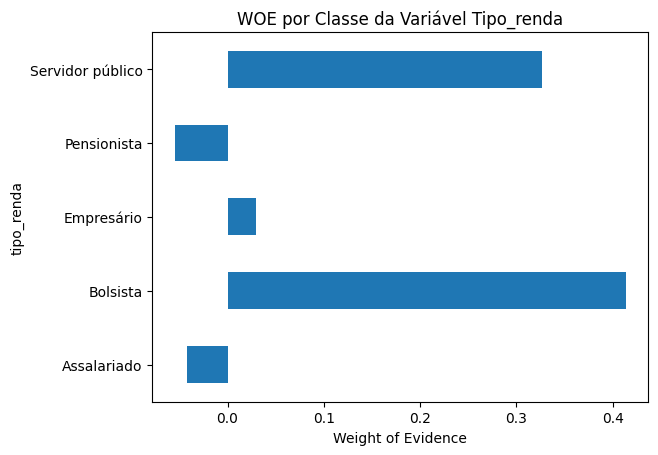

Análise Bivariada da Variável Educacao


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
educacao,,,,,,,
Fundamental,6420,481,6901,0.005698,0.006563,-0.141385,0.000122
Médio,379939,25510,405449,0.337210,0.348088,-0.031751,0.000345
Pós graduação,608,43,651,0.000540,0.000587,-0.083716,0.000004
Superior completo,154354,9086,163440,0.136995,0.123980,0.099823,0.001299
Superior incompleto,22036,1523,23559,0.019558,0.020782,-0.060696,0.000074
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável educacao: 0.1845%


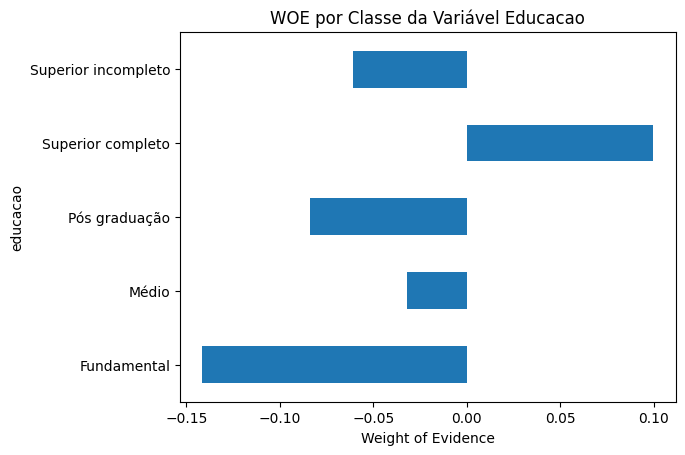

Análise Bivariada da Variável Estado_civil


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
estado_civil,,,,,,,
Casado,395880,25269,421149,0.351358,0.344800,0.018842,0.000124
Separado,31994,2194,34188,0.028396,0.029938,-0.052869,0.000082
Solteiro,68585,4636,73221,0.060872,0.063259,-0.038469,0.000092
União,43048,3060,46108,0.038207,0.041754,-0.088790,0.000315
Viúvo,23850,1484,25334,0.021168,0.020249,0.044352,0.000041
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável estado_civil: 0.0653%


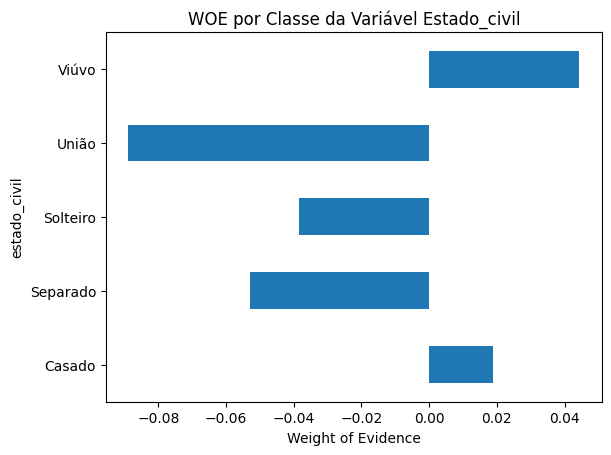

Análise Bivariada da Variável Tipo_residencia


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
tipo_residencia,,,,,,,
Aluguel,7666,596,8262,0.006804,0.008133,-0.178382,0.000237
Casa,506887,32449,539336,0.449881,0.442772,0.015927,0.000113
Com os pais,24733,1997,26730,0.021951,0.027249,-0.216199,0.001145
Comunitário,2449,185,2634,0.002174,0.002524,-0.149612,0.000052
Estúdio,4071,225,4296,0.003613,0.003070,0.162852,0.000088
Governamental,17551,1191,18742,0.015577,0.016251,-0.042373,0.000029
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável tipo_residencia: 0.1665%


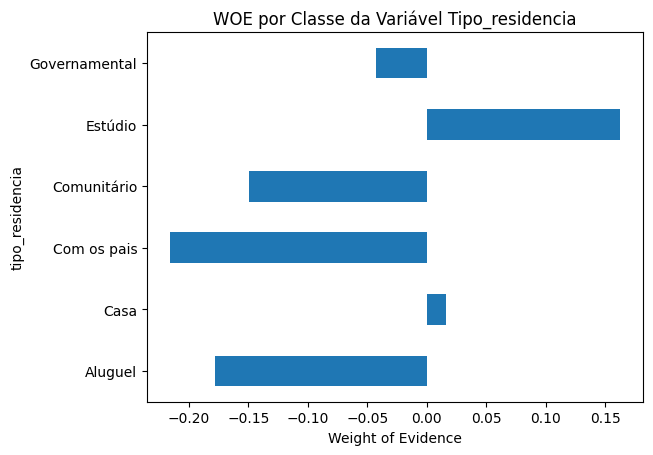

Análise Bivariada da Variável Idade


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
cat_idade,,,,,,,
"(21.999, 29.0]",61628,5356,66984,0.054697,0.073084,-0.289792,0.005328
"(29.0, 33.0]",63496,4655,68151,0.056355,0.063518,-0.119656,0.000857
"(33.0, 36.0]",46010,3079,49089,0.040836,0.042013,-0.028437,0.000033
"(36.0, 40.0]",69989,4624,74613,0.062118,0.063095,-0.015613,0.000015
"(40.0, 43.0]",49264,2852,52116,0.043724,0.038916,0.116482,0.000560
"(43.0, 47.0]",59192,3618,62810,0.052535,0.049368,0.062174,0.000197
"(47.0, 51.0]",55222,2916,58138,0.049012,0.039789,0.208457,0.001922
"(51.0, 55.0]",49126,2696,51822,0.043601,0.036787,0.169928,0.001158
"(55.0, 60.0]",61785,3708,65493,0.054836,0.050596,0.080477,0.000341


Information Value (IV) da variável cat_idade: 1.0420%


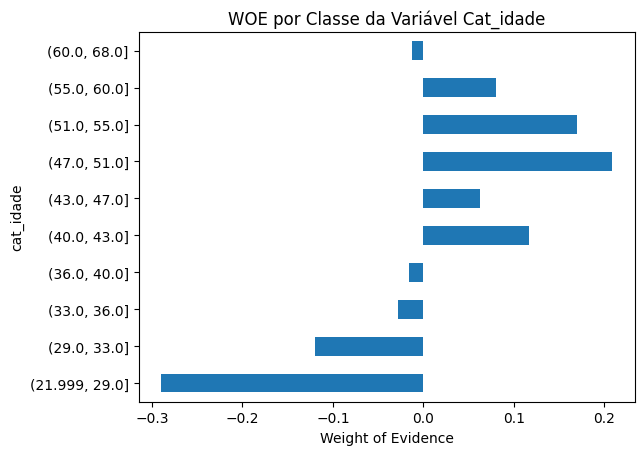

Análise Bivariada da Variável Tempo_emprego


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
cat_tempo_emprego,,,,,,,
"(0.11699999999999999, 1.195]",44598,5510,50108,0.047550,0.091331,-0.652711,0.028576
"(1.195, 2.364]",45006,4770,49776,0.047985,0.079065,-0.499386,0.015521
"(2.364, 3.63]",45691,4257,49948,0.048715,0.070562,-0.370499,0.008094
"(3.63, 4.693]",46190,3830,50020,0.049247,0.063484,-0.253937,0.003615
"(4.693, 6.047]",46750,3339,50089,0.049844,0.055346,-0.104692,0.000576
"(6.047, 7.458]",46944,2685,49629,0.050051,0.044505,0.117440,0.000651
"(7.458, 9.093]",47612,2315,49927,0.050763,0.038372,0.279840,0.003468
"(9.093, 11.726]",48265,1960,50225,0.051460,0.032488,0.459927,0.008726
"(11.726, 16.545]",48567,1057,49624,0.051782,0.017520,1.083674,0.037128


Information Value (IV) da variável cat_tempo_emprego: 19.5608%


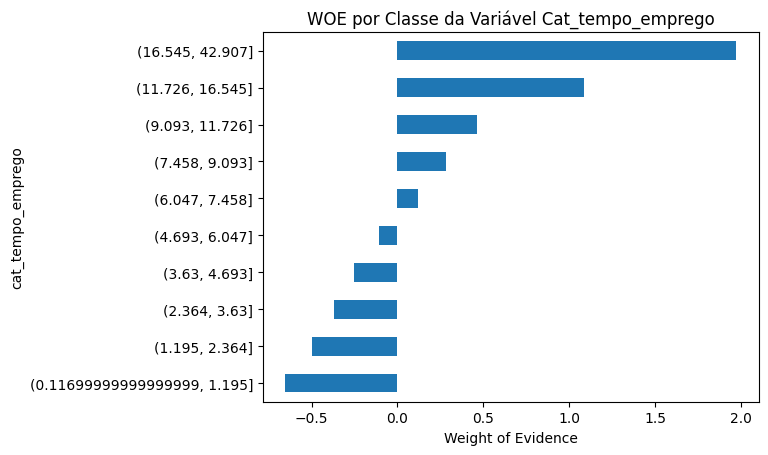

Análise Bivariada da Variável Qt_pessoas_residencia


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
cat_qt_pessoas_residencia,,,,,,,
"(0.999, 2.0]",408788,26050,434838,0.362814,0.355457,0.020488,1.507418e-04
"(2.0, 3.0]",97323,6803,104126,0.086378,0.092828,-0.072019,4.645519e-04
"(3.0, 4.0]",50051,3263,53314,0.044422,0.044524,-0.002296,2.343734e-07
"(4.0, 15.0]",7195,527,7722,0.006386,0.007191,-0.118750,9.561501e-05
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000e+00


Information Value (IV) da variável cat_qt_pessoas_residencia: 0.0711%


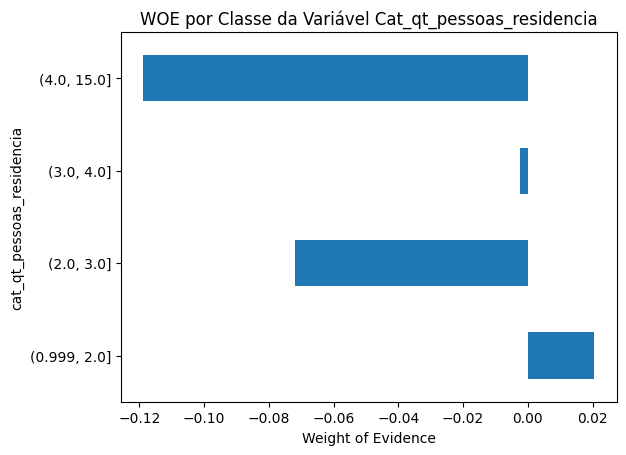

Análise Bivariada da Variável Renda


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
cat_renda,,,,,,,
"(161.859, 2450.919]",46939,13061,60000,0.041660,0.178220,-1.453473,0.198486
"(2450.919, 3905.11]",53265,6738,60003,0.047275,0.091941,-0.665175,0.029711
"(3905.11, 5513.49]",55227,4780,60007,0.049016,0.065224,-0.285680,0.004630
"(5513.49, 7430.69]",56458,3533,59991,0.050109,0.048208,0.038659,0.000073
"(7430.69, 9887.58]",57236,2764,60000,0.050799,0.037715,0.297813,0.003897
"(9887.58, 13152.38]",57901,2103,60004,0.051389,0.028696,0.582679,0.013223
"(13152.38, 18064.01]",58428,1570,59998,0.051857,0.021423,0.884028,0.026905
"(18064.01, 26666.57]",58888,1114,60002,0.052265,0.015201,1.234989,0.045774
"(26666.57, 49048.516]",59274,721,59995,0.052608,0.009838,1.676596,0.071707


Information Value (IV) da variável cat_renda: 52.8433%


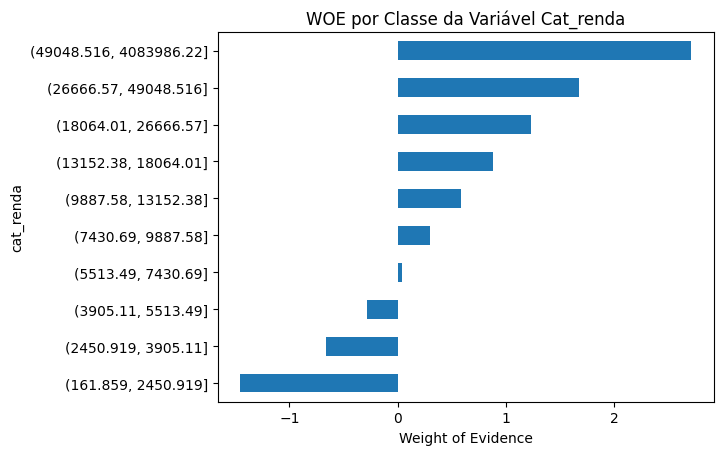

In [10]:
# Conduzindo análise bivariada
for col in data.drop(columns='mau'):
    print(f'Análise Bivariada da Variável {col.capitalize()}')
    if metadata.loc[col, 'tipo_variavel'] == 'contínua':
        analise_bivariada(categorizar_variavel(data[col]), data['mau'])
    else:
        analise_bivariada(data[col], data['mau'])
    print('=' * 120)

In [11]:
# Calculando e salvando Information Value e classificação do mesmo nos metadados
metadata['IV'] = 0.0
metadata['classificação_IV'] = ''

for idx in metadata.index.drop('mau'):
    iv, _ = criar_tabela_woe(data[idx], data['mau'])
    metadata.loc[idx, 'IV'] = iv
    metadata.loc[idx, 'classificação_IV'] = classificar_iv(iv)

metadata

,dtype,num_missings,num_classes,tipo_variavel,papel,IV,classificação_IV
sexo,object,0,2,discreta,independente,0.001333,Inútil
posse_de_veiculo,object,0,2,discreta,independente,0.000037,Inútil
posse_de_imovel,object,0,2,discreta,independente,0.004845,Inútil
qtd_filhos,int64,0,8,contínua,independente,0.000844,Inútil
tipo_renda,object,0,5,discreta,independente,0.004859,Inútil
educacao,object,0,5,discreta,independente,0.001845,Inútil
estado_civil,object,0,5,discreta,independente,0.000653,Inútil
tipo_residencia,object,0,6,discreta,independente,0.001665,Inútil
idade,int64,0,47,contínua,independente,0.012831,Inútil
tempo_emprego,float64,100875,3004,contínua,independente,0.666583,Sobreajuste


Conforme podemos observar na base, todas as variáveis independentes apresentam problemas para serem usadas na construção do modelo, portanto, vamos transforma-las e balancear a base de dados para a construção do modelo.

## Desenvolvimento do modelo

Desenvolva um modelo de *credit scoring* através de uma regressão logística.

- Trate valores missings e outliers
- Trate 'zeros estruturais'
- Faça agrupamentos de categorias conforme vimos em aula
- Proponha uma equação preditiva para 'mau'
- Caso hajam categorias não significantes, justifique

In [12]:
# Substituindo dados missings de tempo_emprego com média
data.fillna(value=data['tempo_emprego'].mean(), inplace=True)
data.isna().sum()

sexo                     0
posse_de_veiculo         0
posse_de_imovel          0
qtd_filhos               0
tipo_renda               0
educacao                 0
estado_civil             0
tipo_residencia          0
idade                    0
tempo_emprego            0
qt_pessoas_residencia    0
renda                    0
mau                      0
dtype: int64

In [13]:
# Fazendo downsampling para balancear a base de dados entre bons e maus pagadores (50/50)
events = data[data['mau'] == True]
not_events = data[data['mau'] == False]

sample_not_events = not_events.sample(n=len(events), random_state=412)

data_balanced = pd.concat([events, sample_not_events]).sample(frac=1, random_state=412).reset_index(drop=True)

data_balanced['mau'].value_counts(normalize=True)

mau
False    0.5
True     0.5
Name: proportion, dtype: float64

In [14]:
print(f'Dimensões da base de desenvolvimento: {data.shape}\nDimensões da base de validação: {data_unseen.shape}\nDimensões da base de desenvolvimento balanceada: {data_balanced.shape}')

Dimensões da base de desenvolvimento: (600000, 13)
Dimensões da base de validação: (150000, 13)
Dimensões da base de desenvolvimento balanceada: (73286, 13)


In [15]:
# Conduzindo uma análise univariada comparativa
for col in data_balanced:
    if metadata[metadata.index == col]['papel'].iloc[0] != 'independente':
        continue
    else:
        print('Análise Univariada Comparativa da Variável {}'.format(col.capitalize()))
        if metadata[metadata.index == col]['tipo_variavel'].iloc[0] == 'discreta':
            tab_1 = pd.DataFrame(data[col].value_counts(normalize=True)).rename({'proportion': 'Proporção Original'}, axis=1)
            tab_2 = pd.DataFrame(data_balanced[col].value_counts(normalize=True)).rename({'proportion': 'Proporção Balanceada'}, axis=1)
            display(pd.concat([tab_1, tab_2], axis=1))
            print('='*100)
        else:
            des_1 = pd.DataFrame(data[col].describe()).rename({'count': 'contagem', 'mean': 'média', 'std': 'desvio padrão'})
            des_2 = pd.DataFrame(data_balanced[col].describe()).rename({'count': 'contagem', 'mean': 'média', 'std': 'desvio padrão'})
            display(pd.concat([des_1, des_2], axis=1))
            print('='*50)

Análise Univariada Comparativa da Variável Sexo


,Proporção Original,Proporção Balanceada
sexo,,
F,0.673008,0.685124
M,0.326992,0.314876


Análise Univariada Comparativa da Variável Posse_de_veiculo


,Proporção Original,Proporção Balanceada
posse_de_veiculo,,
N,0.610488,0.611822
S,0.389512,0.388178


Análise Univariada Comparativa da Variável Posse_de_imovel


...

,tempo_emprego,tempo_emprego
contagem,600000.000000,73286.000000
média,7.747992,6.580919
desvio padrão,6.100461,5.316158
min,0.117808,0.117808
25%,3.635616,2.800000
50%,7.473973,6.068493
75%,9.069863,7.747992
max,42.906849,42.906849


Análise Univariada Comparativa da Variável Qt_pessoas_residencia


,qt_pessoas_residencia,qt_pessoas_residencia
contagem,600000.000000,73286.000000
média,2.212122,2.220683
desvio padrão,0.903757,0.913925
min,1.000000,1.000000
25%,2.000000,2.000000
50%,2.000000,2.000000
75%,3.000000,3.000000
max,15.000000,15.000000


Análise Univariada Comparativa da Variável Renda


,renda,renda
contagem,6.000000e+05,7.328600e+04
média,2.722284e+04,1.788390e+04
desvio padrão,8.737788e+04,7.089482e+04
min,1.618600e+02,1.618600e+02
25%,4.670600e+03,2.748120e+03
50%,9.887580e+03,5.992000e+03
75%,2.162887e+04,1.367219e+04
max,4.083986e+06,3.728517e+06


As propriedades das demais variáveis permaneceram estáveis, contudo a correção feita a base nos permitirá aplicar métricas de avaliação mais robustas, sem a necessidade de correção para avaliação do modelo. Sem contar que a redução de amostras, reduz o custo computacional do modelo.

In [16]:
# Aplicando One-hot encoding nas variáveis categóricas
for col in data_balanced.drop(columns='mau'):
    if metadata.loc[col, 'tipo_variavel'] == 'discreta':
        print(f'Cálculo de IV das Variáveis Criadas: {col}')
        dummies = pd.get_dummies(data_balanced[col], prefix=col)
        data_balanced = pd.concat([data_balanced.drop(col, axis=1), dummies], axis=1)
        ivs, tabs = zip(*[criar_tabela_woe(dummies[column], data_balanced['mau']) for column in dummies])
        for idx in range(len(ivs)):
            print(f'IV de {dummies.columns[idx]}: {ivs[0]:.4%} - {classificar_iv(ivs[idx])}')
        print('='*100)

Cálculo de IV das Variáveis Criadas: sexo
IV de sexo_F: 0.1008% - Inútil
IV de sexo_M: 0.1008% - Inútil
Cálculo de IV das Variáveis Criadas: posse_de_veiculo
IV de posse_de_veiculo_N: 0.0058% - Inútil
IV de posse_de_veiculo_S: 0.0058% - Inútil
Cálculo de IV das Variáveis Criadas: posse_de_imovel
IV de posse_de_imovel_N: 0.5112% - Inútil
IV de posse_de_imovel_S: 0.5112% - Inútil
Cálculo de IV das Variáveis Criadas: tipo_renda
IV de tipo_renda_Assalariado: 0.1056% - Inútil
IV de tipo_renda_Bolsista: 0.1056% - Inútil
IV de tipo_renda_Empresário: 0.1056% - Inútil
IV de tipo_renda_Pensionista: 0.1056% - Inútil
IV de tipo_renda_Servidor público: 0.1056% - Inútil
Cálculo de IV das Variáveis Criadas: educacao
IV de educacao_Fundamental: 0.0061% - Inútil
IV de educacao_Médio: 0.0061% - Inútil
IV de educacao_Pós graduação: 0.0061% - Inútil
IV de educacao_Superior completo: 0.0061% - Inútil
IV de educacao_Superior incompleto: 0.0061% - Inútil
Cálculo de IV das Variáveis Criadas: estado_civil
IV d

In [17]:
# Criando lista com as variáveis contínuas
numeric_features = [value for value in metadata.index if metadata.loc[value, 'tipo_variavel'] == 'contínua']

# Criando lista com as variáveis discretas
categorical_features = [value for value in metadata.index if metadata.loc[value, 'tipo_variavel'] == 'discreta']

# Criando objetos para padronizar variáveis contínuas 
scaler = StandardScaler()

# Padronizando variáveis
data_balanced[numeric_features] = scaler.fit_transform(data_balanced[numeric_features])

# Visualizando resultado
data_balanced[numeric_features].head(5)

,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda
0,-0.591779,1.290792,0.819407,-0.241469,-0.025858
1,-0.591779,-0.902838,0.103054,-0.241469,-0.090949
2,2.077500,-0.639603,0.038634,1.946910,0.008126
3,-0.591779,1.817263,0.219535,-0.241469,-0.228472
4,-0.591779,1.378537,0.012350,-0.241469,-0.232090


In [18]:
# Recalculando Information Value das variáveis padronizadas
for col in data_balanced[numeric_features]:
    iv, _ = criar_tabela_woe(data_balanced[col], data_balanced['mau'])
    print(f"IV da variável {col} antes: {metadata.loc[col, 'IV']:.2%} - {metadata.loc[col, 'classificação_IV']}")
    print(f'IV da variável {col} depois: {iv:.2%} - {classificar_iv(iv)}')
    print('='*75)

IV da variável qtd_filhos antes: 0.08% - Inútil
IV da variável qtd_filhos depois: 0.11% - Inútil
IV da variável idade antes: 1.28% - Inútil
IV da variável idade depois: 1.53% - Inútil
IV da variável tempo_emprego antes: 66.66% - Sobreajuste
IV da variável tempo_emprego depois: 62.47% - Sobreajuste
IV da variável qt_pessoas_residencia antes: 0.16% - Inútil
IV da variável qt_pessoas_residencia depois: 0.18% - Inútil
IV da variável renda antes: 490.00% - Sobreajuste
IV da variável renda depois: 909.53% - Sobreajuste


In [19]:
# Transformando tipos dos dados para processamento
data_balanced[data_balanced.columns[~(data_balanced.columns.isin(numeric_features))]] = data_balanced[data_balanced.columns[~(data_balanced.columns.isin(numeric_features))]].astype(np.int64)

# Visualizando
data_balanced.head(5)

,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda,mau,sexo_F,sexo_M,posse_de_veiculo_N,posse_de_veiculo_S,...,estado_civil_Separado,estado_civil_Solteiro,estado_civil_União,estado_civil_Viúvo,tipo_residencia_Aluguel,tipo_residencia_Casa,tipo_residencia_Com os pais,tipo_residencia_Comunitário,tipo_residencia_Estúdio,tipo_residencia_Governamental
0,-0.591779,1.290792,0.819407,-0.241469,-0.025858,0,1,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,-0.591779,-0.902838,0.103054,-0.241469,-0.090949,1,0,1,0,1,...,0,0,0,0,0,0,1,0,0,0
2,2.077500,-0.639603,0.038634,1.946910,0.008126,1,0,1,0,1,...,0,0,0,0,0,1,0,0,0,0
3,-0.591779,1.817263,0.219535,-0.241469,-0.228472,0,1,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,-0.591779,1.378537,0.012350,-0.241469,-0.232090,1,0,1,0,1,...,0,0,0,0,0,1,0,0,0,0


In [20]:
# Separando base de desenvolvimento em variáveis independentes e dependete
X = data_balanced.drop(columns='mau')
y = data_balanced['mau']

# Separando base de desenvolvimento em bases de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=412)

# Visualizando
print(f'Tamanho da base de treino: {X_train.shape}\nTamanho da base de teste: {X_test.shape}')

Tamanho da base de treino: (51300, 32)
Tamanho da base de teste: (21986, 32)


In [21]:
# Criando objetos para reduzir as dimensões das variáveis
pca = PCA(n_components=15)

# Criando componentes principais
principal_components = pca.fit(X_train)

# Visualizando variância capturada na combinação linear
print('Variância Explicada na Base de Treino:')
print(principal_components.explained_variance_ratio_)

Variância Explicada na Base de Treino:
[0.28022492 0.18477501 0.11114508 0.07050695 0.06085186 0.05284945
 0.04879474 0.03720089 0.03586578 0.03346779 0.01504886 0.01409781
 0.01330778 0.0097738  0.00892523]


In [22]:
# Transformando bases de treino e teste
X_train = pd.DataFrame(principal_components.transform(X_train), columns=[f'PC_{num+1}' for num in range(len(principal_components.components_))])
X_test = pd.DataFrame(principal_components.transform(X_test), columns=[f'PC_{num+1}' for num in range(len(principal_components.components_))])

# Visualizando
display(X_train.head(5))
display(X_test.head(5))

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12,PC_13,PC_14,PC_15
0,-1.519613,0.326001,-1.487650,0.163597,0.477879,0.111120,-0.046872,-0.052934,-0.379641,0.149460,0.308966,-0.134291,-0.028754,-0.245677,0.020099
1,1.824442,-0.414615,0.734441,1.065818,-0.261192,0.303331,0.692870,-0.951338,0.035572,0.356013,-0.034328,-0.314763,-0.128911,-0.164747,0.104600
2,1.800702,-0.147625,0.972895,0.295564,0.193723,0.722154,0.521760,-0.509733,0.326933,1.292775,-0.068875,-0.308435,-0.096763,-0.126627,0.104523
3,-1.436924,-0.783367,0.253520,0.800532,0.518753,-0.928836,0.883532,0.502502,0.545898,0.192893,-0.431700,0.327590,-0.385712,-0.012455,-0.421125
4,-0.143251,-0.536690,0.542818,-0.264351,-0.577695,1.023459,-0.509171,-0.118727,-0.199264,0.907621,-0.205169,-0.181836,-0.092495,0.013610,0.007789


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12,PC_13,PC_14,PC_15
0,-0.656085,-0.410752,-0.473551,0.407578,0.257089,0.000959,-0.722580,-0.616187,-0.298568,0.060186,-0.234860,0.115960,-0.056158,0.116082,-0.104305
1,-2.296929,-0.127821,-1.223573,0.360765,0.342833,-0.026575,-0.089216,0.477613,0.519588,-0.148544,0.279386,-0.189913,0.059602,-0.109889,0.433178
2,0.163942,-1.074283,0.827592,-0.231088,0.114150,0.075431,1.654280,-0.270967,-0.619001,-0.467093,-0.363625,-0.042710,-0.099315,-0.038002,0.047036
3,0.699073,-1.160110,1.759365,-0.045922,-0.378002,0.449200,0.392925,-0.897866,-0.396318,-0.732501,0.782520,0.588019,0.218241,-0.408545,0.177394
4,-0.829358,-1.359973,0.790823,0.153224,0.592888,0.101614,-1.068956,0.546173,0.887065,0.615310,-0.050704,-0.031822,-0.378967,-0.021700,-0.363757


In [23]:
# Calculando Information Value das componentes principais
for comp in X_train:
    iv, _ = criar_tabela_woe(X_train[comp], y_train)
    print(f'IV do componente {comp} igual a : {iv:.2%} - {classificar_iv(iv)}')

IV do componente PC_1 igual a : 1049.52% - Sobreajuste
IV do componente PC_2 igual a : 1049.52% - Sobreajuste
IV do componente PC_3 igual a : 1049.52% - Sobreajuste
IV do componente PC_4 igual a : 1049.52% - Sobreajuste
IV do componente PC_5 igual a : 1049.52% - Sobreajuste
IV do componente PC_6 igual a : 1049.52% - Sobreajuste
IV do componente PC_7 igual a : 1049.52% - Sobreajuste
IV do componente PC_8 igual a : 1049.52% - Sobreajuste
IV do componente PC_9 igual a : 1049.52% - Sobreajuste
IV do componente PC_10 igual a : 1049.52% - Sobreajuste
IV do componente PC_11 igual a : 1049.52% - Sobreajuste
IV do componente PC_12 igual a : 1049.52% - Sobreajuste
IV do componente PC_13 igual a : 1049.52% - Sobreajuste
IV do componente PC_14 igual a : 1049.52% - Sobreajuste
IV do componente PC_15 igual a : 1049.52% - Sobreajuste


Dado a alta chance do modelo de enfrentar **sobreajuste**, vamos aplicar regularização **Elastic Net** de forma a penalizar parâmetros do modelo e evitar sobreajuste.

In [40]:
# Criando o modelo
logistic = LogisticRegression(penalty='elasticnet', C=100, solver='saga', l1_ratio=.5, max_iter=1000)

# Treinando o modelo
logistic.fit(X_train, y_train)

LogisticRegression(C=100, l1_ratio=0.5, max_iter=1000, penalty='elasticnet',
                   solver='saga')

## Avaliação do modelo

Avalie o poder discriminante do modelo pelo menos avaliando acurácia, KS e Gini.

Avalie estas métricas nas bases de desenvolvimento e *out of time*.

                    Métricas do modelo na base de treino                   
Acurácia do modelo na base de treino: 68.20%
AUC do modelo na base de treino: 68.21%
Coeficiente de Gini do modelo na base de treino: 36.41%
KS do modelo na base de treino: 0.3883
              precision    recall  f1-score   support

           0       0.76      0.53      0.62     25651
           1       0.64      0.83      0.72     25649

    accuracy                           0.68     51300
   macro avg       0.70      0.68      0.67     51300
weighted avg       0.70      0.68      0.67     51300



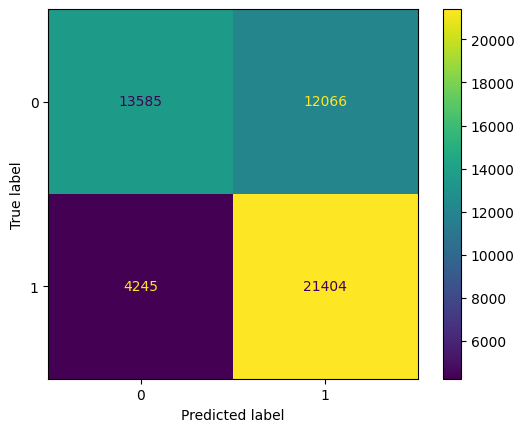

                    Métricas do modelo na base de teste                    
Acurácia do modelo na base de teste: 68.47%
AUC do modelo na base de teste: 68.47%
Coeficiente de Gini do modelo na base de teste: 36.94%
KS do modelo na base de teste: 0.3982
              precision    recall  f1-score   support

           0       0.77      0.53      0.63     10992
           1       0.64      0.84      0.73     10994

    accuracy                           0.68     21986
   macro avg       0.70      0.68      0.68     21986
weighted avg       0.70      0.68      0.68     21986



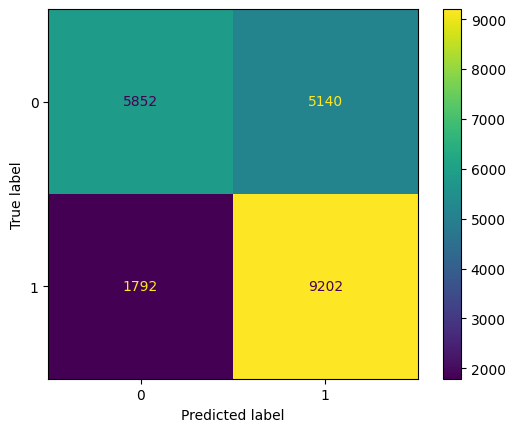

In [42]:
# Criando previsão de classes com a base de treino
y_pred_train = logistic.predict(X_train)

# Criando previsão de probabilidades com base de treino
y_probs_train = logistic.predict_proba(X_train)

# Calculando métricas na base de treinamento
acc_train = accuracy_score(y_train, y_pred_train)
auc_train = roc_auc_score(y_train, y_pred_train)
gini_train = 2 * auc_train - 1
fpr, tpr, _ = roc_curve(y_train, y_probs_train[:, 1])
ks_train = max(tpr - fpr)
cls_report_train = classification_report(y_train, y_pred_train)

# Criando previsão de classes com a base de teste
y_pred_test = logistic.predict(X_test)

# Criando previsão de probabilidades com base de teste
y_probs_test = logistic.predict_proba(X_test)

# Calculando métricas na base de teste
acc_test = accuracy_score(y_test, y_pred_test)
auc_test = roc_auc_score(y_test, y_pred_test)
gini_test = 2 * auc_test - 1
fpr, tpr, _ = roc_curve(y_test, y_probs_test[:, 1])
ks_test = max(tpr - fpr)
cls_report_test = classification_report(y_test, y_pred_test)

# Visualizando métricas na base de treino
print('='*75)
print('Métricas do modelo na base de treino'.center(75))
print('='*75)
print(f'Acurácia do modelo na base de treino: {acc_train:.2%}')
print(f'AUC do modelo na base de treino: {auc_train:.2%}')
print(f'Coeficiente de Gini do modelo na base de treino: {gini_train:.2%}')
print(f'KS do modelo na base de treino: {ks_train:.4f}')
print(cls_report_train)

# Criando e plotando matrix de confusão na base de treino
cm = confusion_matrix(y_train, y_pred_train)
cm_disp = ConfusionMatrixDisplay(cm)
cm_disp.plot()
plt.show()

# Visualizando métricas na base de teste
print('='*75)
print('Métricas do modelo na base de teste'.center(75))
print('='*75)
print(f'Acurácia do modelo na base de teste: {acc_test:.2%}')
print(f'AUC do modelo na base de teste: {auc_test:.2%}')
print(f'Coeficiente de Gini do modelo na base de teste: {gini_test:.2%}')
print(f'KS do modelo na base de teste: {ks_test:.4f}')
print(cls_report_test)

# Criando e plotando matrix de confusão na base de teste
cm = confusion_matrix(y_test, y_pred_test)
cm_disp = ConfusionMatrixDisplay(cm)
cm_disp.plot()
plt.show()

In [46]:
# Avaliando modelo na base de validação

# Tratando valores mising na base de validação
data_unseen.fillna(data_unseen['tempo_emprego'].mean(), inplace=True)
X_unseen = data_unseen.drop(columns='mau')
y_unseen = data_unseen['mau']

# One-hot encoding das variáveis discretas
for col in X_unseen:
    if metadata.loc[col, 'tipo_variavel'] == 'discreta':
        dummies = pd.get_dummies(X_unseen[col], prefix=col)
        X_unseen = pd.concat([X_unseen.drop(col, axis=1), dummies.astype(np.int64)], axis=1)
        
# Padronizando variáveis contínuas
X_unseen[numeric_features] = scaler.fit_transform(X_unseen[numeric_features])

# Combinando variáveis
X_unseen = pd.DataFrame(principal_components.transform(X_unseen), columns=[f'PC_{num+1}' for num in range(len(principal_components.components_))])

# Calculando acurácia e classificação
y_pred = logistic.predict(X_unseen)
print(f'Acurácia do modelo final igual a {accuracy_score(y_unseen, y_pred):.2%}')
print(classification_report(y_unseen, y_pred))

Acurácia do modelo final igual a 42.87%
              precision    recall  f1-score   support

       False       0.96      0.35      0.51    128000
        True       0.19      0.91      0.32     22000

    accuracy                           0.43    150000
   macro avg       0.58      0.63      0.41    150000
weighted avg       0.85      0.43      0.48    150000



## Criar um pipeline utilizando o sklearn pipeline 

## Pré processamento

### Substituição de nulos (nans)

Existe nulos na base? é dado numérico ou categórico? qual o valor de substituição? média? valor mais frequente? etc

### Remoção de outliers

Como identificar outlier? Substituir o outlier por algum valor? Remover a linha?

### Seleção de variáveis

Qual tipo de técnica? Boruta? Feature importance? 

### Redução de dimensionalidade (PCA)

Aplicar PCA para reduzir a dimensionalidade para 5

### Criação de dummies

Aplicar o get_dummies() ou onehotencoder() para transformar colunas catégoricas do dataframe em colunas de 0 e 1. 
- sexo
- posse_de_veiculo
- posse_de_imovel
- tipo_renda
- educacao
- estado_civil
- tipo_residencia

### Pipeline 

Crie um pipeline contendo essas funções.

preprocessamento()
- substituicao de nulos
- remoção outliers
- PCA
- Criação de dummy de pelo menos 1 variável (posse_de_veiculo)

### Treinar um modelo de regressão logistica com o resultado

### Salvar o pickle file do modelo treinado

In [ ]:
import pickle

nome_arquivo = 'model_final.pkl'
pickle.dump(model, open(nome_arquivo, 'wb'))

# Pycaret na base de dados 

Utilize o pycaret para pre processar os dados e rodar o modelo **lightgbm**. Faça todos os passos a passos da aula e gere os gráficos finais. E o pipeline de toda a transformação.



In [4]:
import pandas as pd

df = pd.read_feather('credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


In [ ]:
from pycaret.classification import *
models()

In [ ]:
xxx = create_model('xxx')

### Salvar o arquivo do modelo treinado

# Projeto Final

1. Subir no GITHUB todos os jupyter notebooks/códigos que você desenvolveu nesse ultimo módulo
1. Gerar um arquivo python (.py) com todas as funções necessárias para rodar no streamlit a escoragem do arquivo de treino
    - Criar um .py
    - Criar um carregador de csv no streamlit 
    - Subir um csv no streamlit 
    - Criar um pipeline de pré processamento dos dados
    - Utilizar o modelo treinado para escorar a base 
        - nome_arquivo = 'model_final.pkl'
1. Gravar um vídeo da tela do streamlit em funcionamento (usando o próprio streamlit (temos aula disso) ou qlqr outra forma de gravação).
1. Subir no Github o vídeo de funcionamento da ferramenta como README.md.
1. Subir no Github os códigos desenvolvidos. 
1. Enviar links do github para o tutor corrigir.